In [1]:
df <- read.csv("https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/cbb.csv")

In [3]:
colnames(df)

[1] "TEAM"       "CONF"       "G"          "W"          "ADJOE"     
 [6] "ADJDE"      "BARTHAG"    "EFG_O"      "EFG_D"      "TOR"       
[11] "TORD"       "ORB"        "DRB"        "FTR"        "FTRD"      
[16] "X2P_O"      "X2P_D"      "X3P_O"      "X3P_D"      "ADJ_T"     
[21] "WAB"        "POSTSEASON" "SEED"       "YEAR"

In [2]:
model <- lm(W ~ EFG_O + TOR + ORB + FTR, df)
summary(model)
coeffs <- abs(coef(model)[-1])
coeffs / sum(coeffs) * 100


Call:
lm(formula = W ~ EFG_O + TOR + ORB + FTR, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-13.3986  -2.9140  -0.0847   2.8572  14.2176 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -45.06306    1.50256  -29.99   <2e-16 ***
EFG_O         1.12558    0.02201   51.15   <2e-16 ***
TOR          -0.98110    0.03183  -30.82   <2e-16 ***
ORB           0.62216    0.01587   39.21   <2e-16 ***
FTR           0.14057    0.01235   11.38   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.077 on 4244 degrees of freedom
Multiple R-squared:  0.6066,	Adjusted R-squared:  0.6062 
F-statistic:  1636 on 4 and 4244 DF,  p-value: < 2.2e-16


EFG_O       TOR       ORB       FTR 
39.226945 34.191556 21.682510  4.898989

Task: Your boss noted that the relative importance of the Four
Factors may vary by season. She wants a visualization to
compare the magnitude of these effects over time. Create a line
graph showing the regression coefficients for each factor by year.

Warning message:
"package 'tidyverse' was built under R version 4.5.2"
Warning message:
"package 'ggplot2' was built under R version 4.5.2"
Warning message:
"package 'tidyr' was built under R version 4.5.2"
Warning message:
"package 'dplyr' was built under R version 4.5.2"
Warning message:
"package 'stringr' was built under R version 4.5.2"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


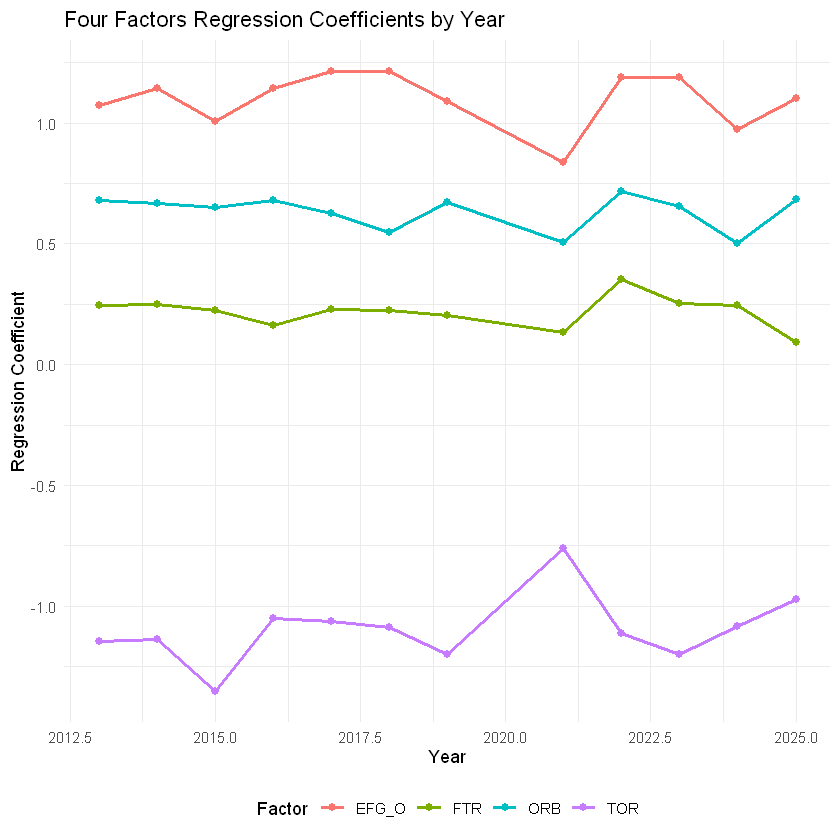

In [4]:
library(tidyverse)
results <- df %>%
  group_by(YEAR) %>%
  group_modify(~ {
    model <- lm(W ~ EFG_O + TOR + ORB + FTR, data = .x)
    coef(model)[-1] %>%
      enframe(name = "Factor", value = "Coefficient")
  }) %>%
  ungroup()

ggplot(results, aes(x = YEAR, y = Coefficient, color = Factor, group = Factor)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Four Factors Regression Coefficients by Year",
    x = "Year",
    y = "Regression Coefficient",
    color = "Factor"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")